In [1]:
import os
import glob
import numpy as np
import pandas as pd
import lightkurve as lk
from scipy.interpolate import interp1d
from astropy.timeseries import BoxLeastSquares
import concurrent.futures
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress annoying warnings from lightkurve/astropy
warnings.filterwarnings('ignore')

In [2]:
# --- CONFIGURATION ---
KOI_FILE = "q1_q8_koi_2025.02.03_04.12.15.csv" # Ensure this file is in the folder
OUTPUT_DIR = "pipeline_output_v1"
BATCH_SIZE = 50          # Save to disk every 50 stars (Prevents RAM crashes)
CNN_INPUT_LEN = 2000     # Size of array for CNN input
WORKERS = 4              # Keep low (4-8) to prevent API timeouts

# --- FILTERING SETTINGS ---
# "Narrowing our topic": Set these to filter your dataset
FILTER_PERIOD_MIN = 50.0   # e.g., only looking for periods > 50 days
FILTER_PERIOD_MAX = 500.0
FILTER_RADIUS_MAX = 4.0    # e.g., only planets smaller than Neptune (4 Earth Radii)

# --- BATMAN SETUP ---
try:
    import batman
    HAVE_BATMAN = True
    print("Batman package found. Using realistic injection.")
except ImportError:
    HAVE_BATMAN = False
    print("Batman not found. Falling back to simple box injection.")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

Batman package found. Using realistic injection.


In [3]:
def get_catalog():
    print(f"Loading {KOI_FILE}...")
    df = pd.read_csv(KOI_FILE, comment='#')
    
    # Filter 1: Valid Kepler ID and Status
    df = df[df['kepid'].notna()]
    
    # Filter 2: Apply Project Criteria
    # (Logic: Keep Confirmed planets that match criteria, OR keep all False Positives for noise)
    
    confirmed = df[df['koi_disposition'] == 'CONFIRMED'].copy()
    false_pos = df[df['koi_disposition'] == 'FALSE POSITIVE'].copy()
    
    # Apply filters ONLY to the confirmed planets we want to find
    if FILTER_PERIOD_MIN:
        confirmed = confirmed[confirmed['koi_period'] > FILTER_PERIOD_MIN]
    if FILTER_PERIOD_MAX:
        confirmed = confirmed[confirmed['koi_period'] < FILTER_PERIOD_MAX]
    if FILTER_RADIUS_MAX:
        confirmed = confirmed[confirmed['koi_prad'] < FILTER_RADIUS_MAX]
        
    print(f"  Confirmed Planets remaining after filters: {len(confirmed)}")
    print(f"  False Positives available for noise: {len(false_pos)}")
    
    return confirmed, false_pos

In [4]:
# --- HELPER: SAFE SAMPLING ---
def safe_sample(df, n_samples, random_state=42):
    """
    Safely samples n_samples from df. 
    If df has fewer rows than n_samples, returns ALL rows.
    """
    available = len(df)
    if available == 0:
        return df
    
    if available < n_samples:
        print(f"  Warning: Requested {n_samples} samples, but only {available} passed filters. Taking all of them.")
        return df
    
    return df.sample(n=n_samples, random_state=random_state)

In [5]:
# --- 2. INJECTION LOGIC ---
def inject_batman_transit(lc, period, t0, r_planet_earth, r_star_sun):
    """
    Injects a realistic transit using the Batman package.
    """
    if not HAVE_BATMAN:
        time = lc.time.value
        duration_days = 0.2 # Arbitrary duration for fallback
        depth = 0.01        # Arbitrary depth
        phase = ((time - t0 + 0.5 * period) % period) - 0.5 * period
        intransit = np.abs(phase) < (duration_days / 2.0)
        flux_inj = lc.flux.value * (1.0 - depth * intransit.astype(float))
        return lk.LightCurve(time=time, flux=flux_inj, flux_err=lc.flux_err)
        
    time = lc.time.value
    
    # Convert Earth Radii to Stellar Radii units (Approximate)
    # 1 Solar Radius = 109 Earth Radii
    rp_rs = (r_planet_earth / 109.0) / r_star_sun
    
    params = batman.TransitParams()
    params.t0 = t0                       # time of inferior conjunction
    params.per = period                  # orbital period
    params.rp = rp_rs                    # planet radius (in units of stellar radii)
    params.a = 15.0                      # semi-major axis (in units of stellar radii) - simple assumption
    params.inc = 90.0                    # orbital inclination (in degrees)
    params.ecc = 0.0                     # eccentricity
    params.w = 90.0                      # longitude of periastron (in degrees)
    params.u = [0.1, 0.3]                # limb darkening coefficients
    params.limb_dark = "quadratic"       
    
    m = batman.TransitModel(params, time)
    flux_model = m.light_curve(params)
    
    # Inject: Multiply flux by the transit model
    new_flux = lc.flux.value * flux_model
    
    return lk.LightCurve(time=time, flux=new_flux, flux_err=lc.flux_err)

In [6]:
# --- 3. PROCESSING WORKER ---
def process_star(task):
    row = task['row']
    inject_mode = task['inject']
    
    kic = int(row['kepid'])
    
    # Data extraction for Bayesian Team
    period = row.get('koi_period', 0)
    prad = row.get('koi_prad', 0)
    star_rad = row.get('koi_srad', 1.0) # Default to 1 solar radius if missing
    
    if pd.isna(star_rad): star_rad = 1.0
    
    try:
        # A. Download "Full Data" (Stitched quarters)
        # Using download_all().stitch() gives the most data but is slower. 
        # Ideally, we limit to a few quarters if it crashes, but let's try full first.
        search = lk.search_lightcurve(f"KIC {kic}", author="Kepler", cadence="long")
        
        if len(search) == 0: return None
        
        # Download and Stitch
        # Note: If this hangs often, change to search[0].download() for single quarter
        # Try to download ALL quarters (Best Quality) with a fallback
        try:
            # Attempt to download and stitch everything (Crucial for Long Periods)
            lc_coll = search.download_all() # Downloads only one quarter
            if lc_coll is None: return None
            lc = lc_coll.stitch().normalize().remove_nans()
        except Exception as e:
            # If full download fails (or times out), try just the first quarter as a backup
            # This keeps the pipeline running instead of crashing
            try:
                lc = search[0].download().normalize().remove_nans()
            except:
                return None
        
        # B. Clean & Flatten
        lc = lc.flatten(window_length=901).remove_outliers(sigma=5)
        
        # C. Synthetic Injection (Batman)
        # If this is a "False Positive" used as noise, we inject a fake planet
        is_synthetic = False
        if inject_mode:
            # Randomize injection parameters
            inj_period = np.random.uniform(50, 300) # Long period injection
            inj_t0 = lc.time.value[0] + np.random.uniform(0, inj_period)
            inj_rad = np.random.uniform(1.0, 4.0)   # Earth to Neptune size
            
            lc = inject_batman_transit(lc, inj_period, inj_t0, inj_rad, star_rad)
            
            # Update labels for the model
            period = inj_period
            prad = inj_rad
            is_synthetic = True
            
        # D. Feature Extraction (Bayesian Team)
        # Calculate BLS (Box Least Squares) to find periodicity
        model_features = {'bls_period': 0, 'bls_power': 0, 'snr': 0, 'sigma': 0}
        try:
            bls = BoxLeastSquares(lc.time, lc.flux)
            durations = np.linspace(0.05, 0.5, 10)
            period_grid = np.linspace(1, 400, 5000) # Search grid
            bls_power = bls.power(period_grid, durations)
            
            best_idx = np.argmax(bls_power.power)
            
            model_features['bls_period'] = bls_power.period[best_idx]
            model_features['bls_power'] = bls_power.power[best_idx]
            model_features['snr'] = bls_power.depth[best_idx] / np.std(lc.flux.value)
            model_features['sigma'] = np.std(lc.flux.value)
        except:
            pass

        # E. Flux Processing (CNN Team)
        # Interpolate to fixed size (2000 points)
        f = interp1d(np.linspace(0, 1, len(lc.flux)), lc.flux.value, fill_value="extrapolate")
        flux_fixed = f(np.linspace(0, 1, CNN_INPUT_LEN))
        
        # Normalize (Standard Scaling)
        flux_fixed = (flux_fixed - np.mean(flux_fixed)) / (np.std(flux_fixed) + 1e-6)
        
        return {
            'kic': kic,
            'flux': flux_fixed,
            'label': 1 if (row['koi_disposition'] == 'CONFIRMED' or is_synthetic) else 0,
            'is_synthetic': is_synthetic,
            'period': period,
            'radius': prad if not is_synthetic else inj_rad,
            'star_radius': star_rad,
            'planet_star_ratio': prad / (star_rad * 109.0),
            **model_features
        }

    except Exception as e:
        # print(f"Error on KIC {kic}: {e}")
        return None

In [7]:
# --- 4. BATCH MANAGER ---
def run_pipeline():
    confirmed_df, noise_df = get_catalog()
    
    if len(confirmed_df) == 0 and len(noise_df) == 0:
        print("No stars found. Exiting.")
        return

    # Use SAFE SAMPLE here to prevent crashes
    print("Selecting samples...")
    positives = safe_sample(confirmed_df, 300) #might have to change to ~1000
    negatives = safe_sample(noise_df, 300) #might change to ~800 (same for next line)
    synthetic_hosts = safe_sample(noise_df, 300, random_state=99) # Different random state
    
    tasks = []
    for _, row in positives.iterrows(): tasks.append({'row': row, 'inject': False})
    for _, row in negatives.iterrows(): tasks.append({'row': row, 'inject': False})
    for _, row in synthetic_hosts.iterrows(): tasks.append({'row': row, 'inject': True})
        
    print(f"Total tasks created: {len(tasks)}")
    
    # Process
    chunk_size = BATCH_SIZE
    existing_batches = len(glob.glob(f"{OUTPUT_DIR}/batch_*.npz"))
    start_index = existing_batches * chunk_size
    
    if start_index > 0:
        print(f"Resuming from task {start_index}...")
        tasks = tasks[start_index:]
        
    current_batch = []
    batch_idx = existing_batches
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=WORKERS) as executor:
        futures = {executor.submit(process_star, t): t for t in tasks}
        
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(tasks)):
            try:
                # Add timeout=60 (seconds)
                res = future.result(timeout=60) 
                if res:
                    current_batch.append(res)
            except concurrent.futures.TimeoutError:
                print(f"Task timed out. Skipping.")
            except Exception as e:
                print(f"Task failed: {e}")
            
            if len(current_batch) >= BATCH_SIZE:
                save_batch(current_batch, batch_idx)
                current_batch = []
                batch_idx += 1
                
    if current_batch:
        save_batch(current_batch, batch_idx)

In [8]:
def save_batch(data, idx):
    fluxes = np.array([d['flux'] for d in data])
    meta = pd.DataFrame([{k: v for k, v in d.items() if k != 'flux'} for d in data])
    np.savez_compressed(f"{OUTPUT_DIR}/batch_{idx}.npz", fluxes=fluxes)
    meta.to_csv(f"{OUTPUT_DIR}/batch_{idx}_meta.csv", index=False)

In [9]:
# --- 5. MERGE FUNCTION ---
def merge_outputs():
    print("Merging...")
    flux_files = sorted(glob.glob(f"{OUTPUT_DIR}/batch_*.npz"))
    meta_files = sorted(glob.glob(f"{OUTPUT_DIR}/batch_*_meta.csv"))
    
    if not flux_files: return print("No data to merge.")
    
    X = np.concatenate([np.load(f)['fluxes'] for f in flux_files], axis=0)
    meta = pd.concat([pd.read_csv(f) for f in meta_files], ignore_index=True)
    
    np.save(f"{OUTPUT_DIR}/X_final.npy", X)
    meta.to_csv(f"{OUTPUT_DIR}/metadata_final.csv", index=False)
    print(f"DONE. Final shape: {X.shape}")

In [10]:
if __name__ == "__main__":
    run_pipeline()
    merge_outputs()

Loading q1_q8_koi_2025.02.03_04.12.15.csv...
  Confirmed Planets remaining after filters: 167
  False Positives available for noise: 701
Selecting samples...
Total tasks created: 767
Resuming from task 800...


0it [00:00, ?it/s]

Merging...


DONE. Final shape: (741, 2000)


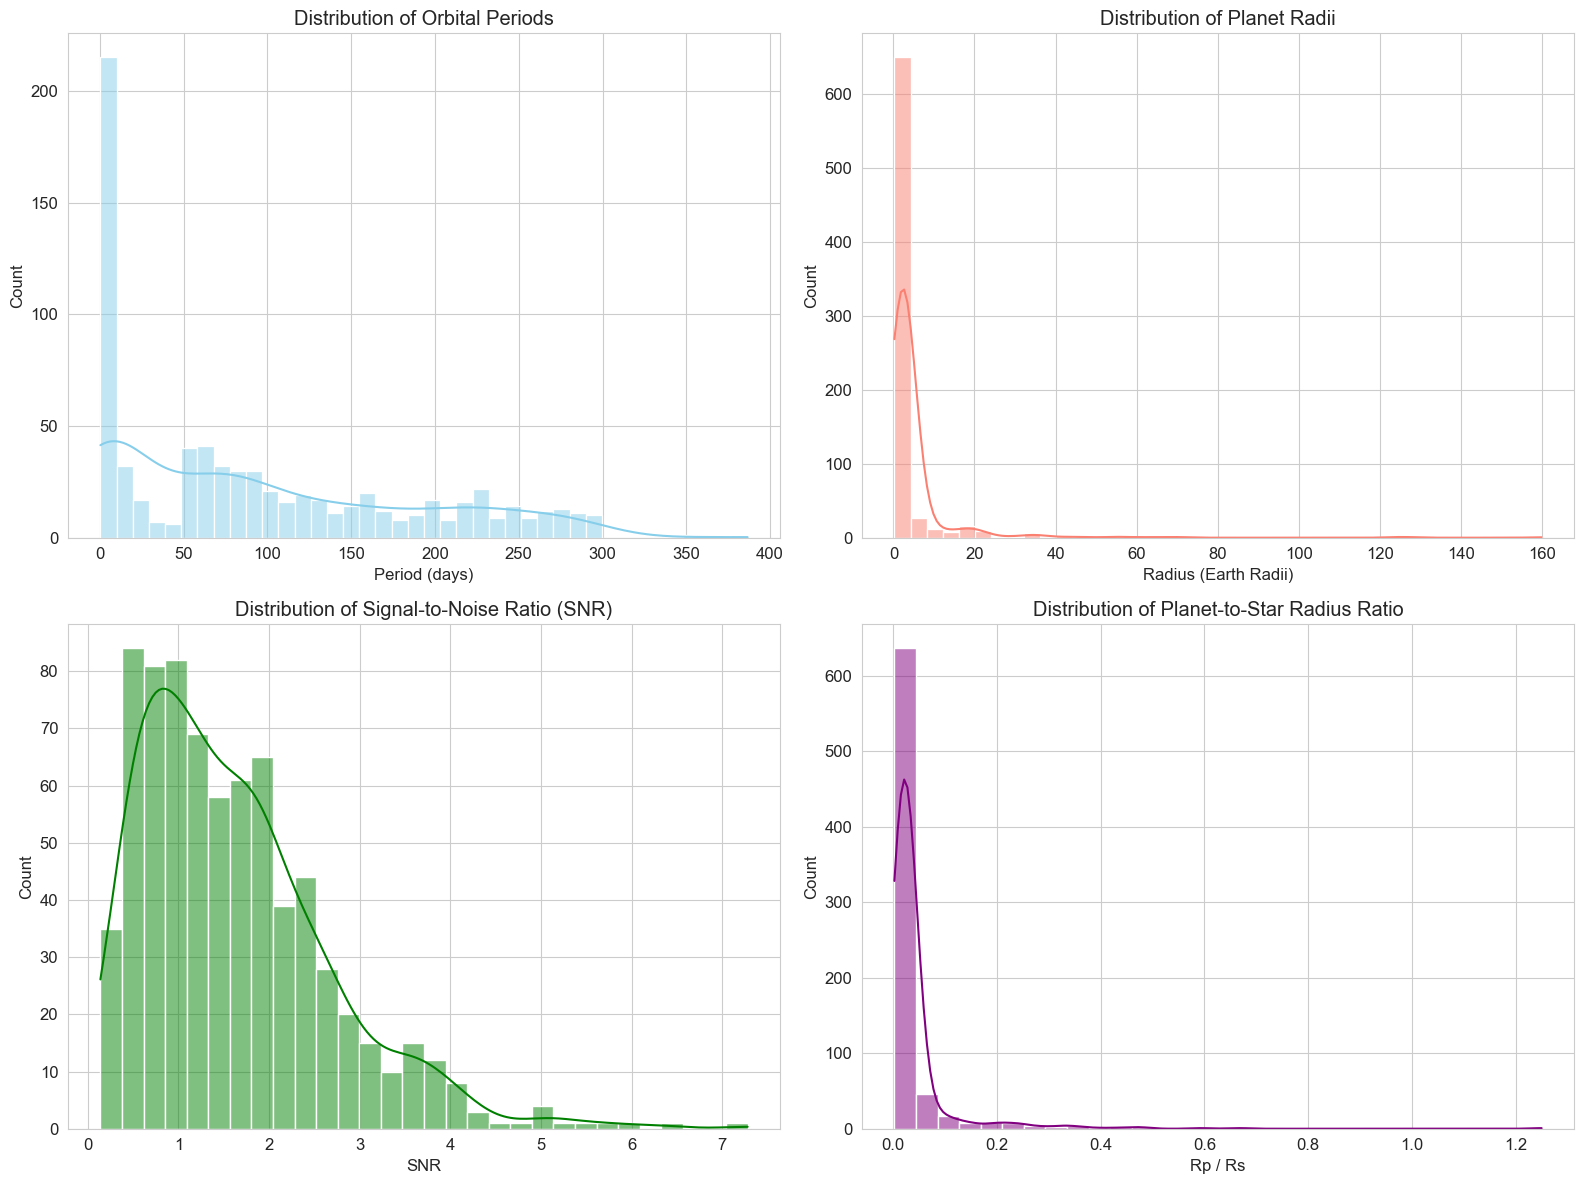

In [11]:
# --- VISUALIZATION ---
df = pd.read_csv(".\pipeline_output_v1\metadata_final.csv") # check that this pathway works...

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot A: Orbital Period Distribution ---
sns.histplot(data=df, x='period', bins=40, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Orbital Periods')
axes[0, 0].set_xlabel('Period (days)')

# --- Plot B: Planet Radius Distribution ---
sns.histplot(data=df, x='radius', bins=40, kde=True, color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Planet Radii')
axes[0, 1].set_xlabel('Radius (Earth Radii)')

# --- Plot C: Signal-to-Noise Ratio (SNR) ---
sns.histplot(data=df, x='snr', bins=30, kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Signal-to-Noise Ratio (SNR)')
axes[1, 0].set_xlabel('SNR')

# --- Plot D: Planet-Star Ratio (New Feature) ---
# Check if the column exists first (since you just added it)
if 'planet_star_ratio' in df.columns:
    sns.histplot(data=df, x='planet_star_ratio', bins=30, kde=True, color='purple', ax=axes[1, 1])
    axes[1, 1].set_title('Distribution of Planet-to-Star Radius Ratio')
    axes[1, 1].set_xlabel('Rp / Rs')
else:
    # Fallback: Scatter Plot of Period vs Radius
    sns.scatterplot(data=df, x='period', y='radius', hue='label', alpha=0.6, ax=axes[1, 1])
    axes[1, 1].set_title('Planet Radius vs. Period')
    axes[1, 1].set_ylabel('Radius (Earth Radii)')

plt.tight_layout()
plt.show()